# This notebook is used to visualy inspect the quality of the ground truths and the proposed regions of interest RoI for the masked R-CNN

In [1]:
dataset_filepath = "/net/vdesk/data2/penchev/project_data/b2s_dataset/"
images_train_filepath = "images"
proposals_train_filepath = "proposals"
annotations_path = "annotations.json"

# Load the json file containing the cutout metadata and proposed RoIs

In [2]:
import json
import os

annotations_path = os.path.join(dataset_filepath, annotations_path)
with open(annotations_path, "r") as f:
    annotations = json.load(f)

# Show the structure of the annotations (COCO format)
for key in annotations.keys():
    key_type = type(annotations[key])
    element_type = type(annotations[key][0]) if isinstance(annotations[key], list) and len(annotations[key]) > 0 else None
    print(f"{key}: {key_type}, element type: {element_type}, length: {len(annotations[key])}")
    if element_type == dict:
        for key2 in annotations[key][0].keys():
            key2_type = type(annotations[key][0][key2])
            element2_type = type(annotations[key][0][key2][0]) if isinstance(annotations[key][0][key2], list) and len(annotations[key][0][key2]) > 0 else None
            print(f"  {key2}: {key2_type}")
            if key2 == "metadata":
                for key3 in annotations[key][0][key2].keys():
                    key3_type = type(annotations[key][0][key2][key3])
                    print(f"    {key3}: {key3_type}")

images: <class 'list'>, element type: <class 'dict'>, length: 752
  id: <class 'int'>
  file_name: <class 'str'>
  width: <class 'int'>
  height: <class 'int'>
  metadata: <class 'dict'>
    RA: <class 'float'>
    DEC: <class 'float'>
    candidates: <class 'dict'>
    rotated: <class 'bool'>
    origin_id: <class 'int'>
    rotation_angle: <class 'int'>
    stretch: <class 'str'>
    grg_in_sample: <class 'bool'>
    reprojected: <class 'bool'>
    old_redshift: <class 'NoneType'>
    new_redshift: <class 'NoneType'>
annotations: <class 'list'>, element type: <class 'dict'>, length: 752
  id: <class 'int'>
  image_id: <class 'int'>
  category_id: <class 'int'>
  gt_component_membership: <class 'list'>
  gt_proposal_validity: <class 'list'>
categories: <class 'list'>, element type: <class 'dict'>, length: 1
  id: <class 'int'>
  name: <class 'str'>


# Display the images with the proposed RoIs and ground truth annotations

In [ ]:
import matplotlib.pyplot as plt
from pycocotools.coco import COCO
import numpy as np
import os

def get_image_by_id(annotations: dict, image_id: int) -> dict:
    """
    Retrieve the image element from the annotations JSON by image ID.
    
    :param annotations: The annotations dictionary containing 'images' list
    :param image_id: The ID of the image to find
    :return: Dictionary containing image metadata (id, file_name, width, height, metadata)
    :raises ValueError: If image_id is not found
    """
    for image in annotations['images']:
        if image['id'] == image_id:
            return image
    raise ValueError(f"Image with id {image_id} not found in annotations")

def plot_image_with_boxes_proposals(annotations: dict, annotations_path: str, id: int):
    """
    Plot an image with bounding boxes overlaid.
    
    :param image_path: Path to the image file
    :param boxes: Array of bounding boxes in the format [x_min, y_min, x_max, y_max]
    """
    image_info = get_image_by_id(annotations, id)
    image_file_name = image_info['file_name']
    proposals = image_file_name.replace(".png", ".npz")
    image_path = os.path.join(dataset_filepath, images_train_filepath, image_file_name)
    proposals_path = os.path.join(dataset_filepath, proposals_train_filepath, proposals)

    components = image_info['metadata']['candidates']['grouping']['components']

    # Get the data for the plotting of the images
    proposal_boxes = np.load(proposals_path)['boxes']

    # Load COCO annotations
    coco = COCO(annotations_path)
    ann_ids = coco.getAnnIds(imgIds=[id], iscrowd=None)
    anns = coco.loadAnns(ann_ids)
    gt_component_membership = anns[0]["gt_component_membership"]
    gt_proposal_validity = anns[0]["gt_proposal_validity"]
    
    fig, ax = plt.subplots(1, 2, figsize=(16, 8))

    img = plt.imread(image_path)
    
    # Plot image and GT
    ax[0].imshow(img)    
    ax[0].set_title("Image")

    for i, prop_val in enumerate(gt_proposal_validity):
        if prop_val == 1:
            x_min, y_min, x_max, y_max = proposal_boxes[i]
            width = x_max - x_min
            height = y_max - y_min
            rect = plt.Rectangle((x_min, y_min), width, height, edgecolor='green', facecolor='none', linewidth=2, label='GT Box' if i == 0 else "")
            ax[0].add_patch(rect)

            # Get the membership of the components in the GT box
            component_membership = gt_component_membership[i]
            # Get the indecies where the component_membership is 1
            comp_in_prop = np.where(component_membership)[0]
            comps_xy = [] # This list contains lists of xy coordinates of the components in the GT box
            for c in components:
                if c['component_id'] in comp_in_prop:
                    comps_xy.append(c['xy'])
                    source_name = c['source_id']
                    ax[0].annotate(f"{source_name}", tuple(c['xy']), color='red', fontsize=10, ha='center')
            comps_xy = np.array(comps_xy)
            x = comps_xy[:, 0]
            y = comps_xy[:, 1]
            ax[0].scatter(x, y, c='black', marker='*', s=10)

            # Annotate the source name on top of the GT box
            ax[0].annotate(
                f"Source {source_name}",
                ((x_min + x_max) / 2, y_min),
                color='red',
                fontsize=10,
                ha='center',
                va='bottom'
            )
            
    ax[1].imshow(img)
    print(f"Plotting {len(proposal_boxes)} proposal boxes on image {image_file_name}")


    for i, box in enumerate(proposal_boxes):
        x_min, y_min, x_max, y_max = box
        width = x_max - x_min
        height = y_max - y_min
        rect = plt.Rectangle((x_min, y_min), width, height, edgecolor='red', facecolor='none', linewidth=2, label='Proposed Box' if i == 0 else "")
        ax[1].add_patch(rect)

    ax[1].set_title("Image with Bounding Boxes")
    plt.legend()
    plt.show()

loading annotations into memory...


Done (t=0.65s)
creating index...
index created!
{'component_id': 5, 'source_id': 5, 'source_name': 'ILTJ000103.49+263955.1', 'component_name': 'ILTJ000103.49+263955.1', 'xy': [41, 181], 'physical': {'total_flux': 1.3228906146787145, 'peak_flux': 0.8330595070543901, 'maj': 8.18176240124017, 'min': 6.9893955793403375}}
Plotting 127 proposal boxes on image LoTSS_B2S_0000000085_rotated_angle315_RA0.239319_DEC26.623834.png


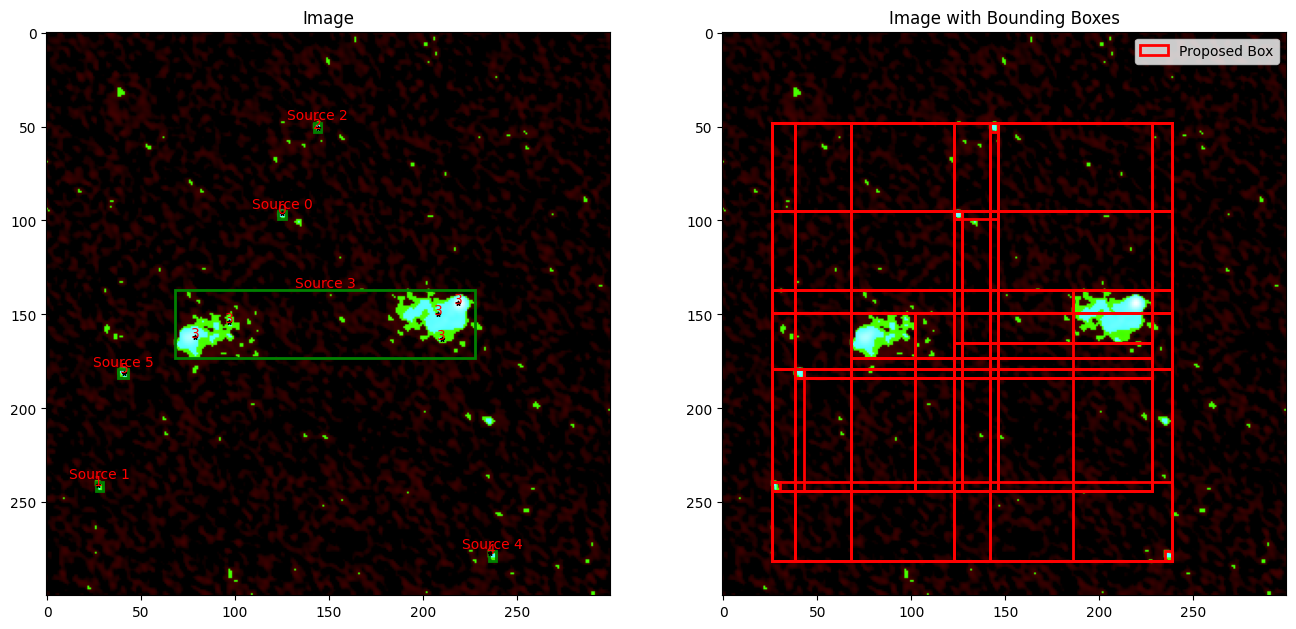

loading annotations into memory...
Done (t=0.68s)
creating index...
index created!
Plotting 7 proposal boxes on image LoTSS_B2S_0000000074_rotated_angle270_RA1.351389_DEC26.351984.png


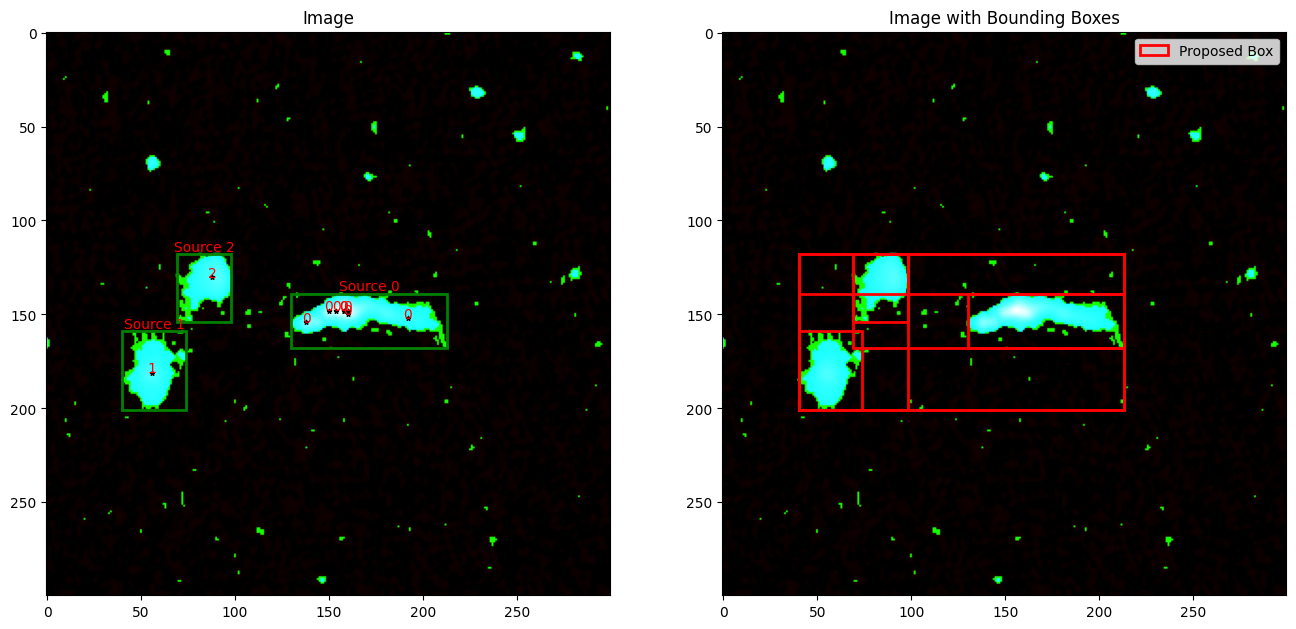

loading annotations into memory...
Done (t=0.62s)
creating index...
index created!
Plotting 255 proposal boxes on image LoTSS_B2S_0000000043_rotated_angle225_RA0.834386_DEC32.488292.png


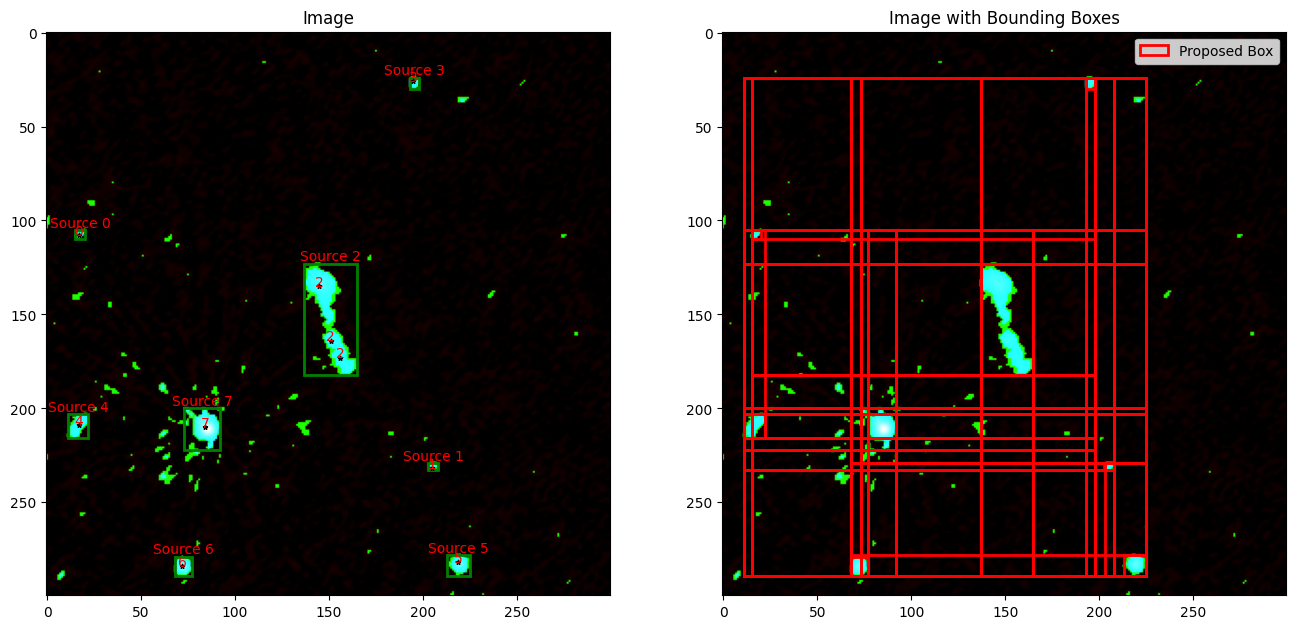

loading annotations into memory...
Done (t=0.64s)
creating index...
index created!
Plotting 63 proposal boxes on image LoTSS_B2S_0000000053_rotated_angle270_RA0.28152_DEC23.87971.png


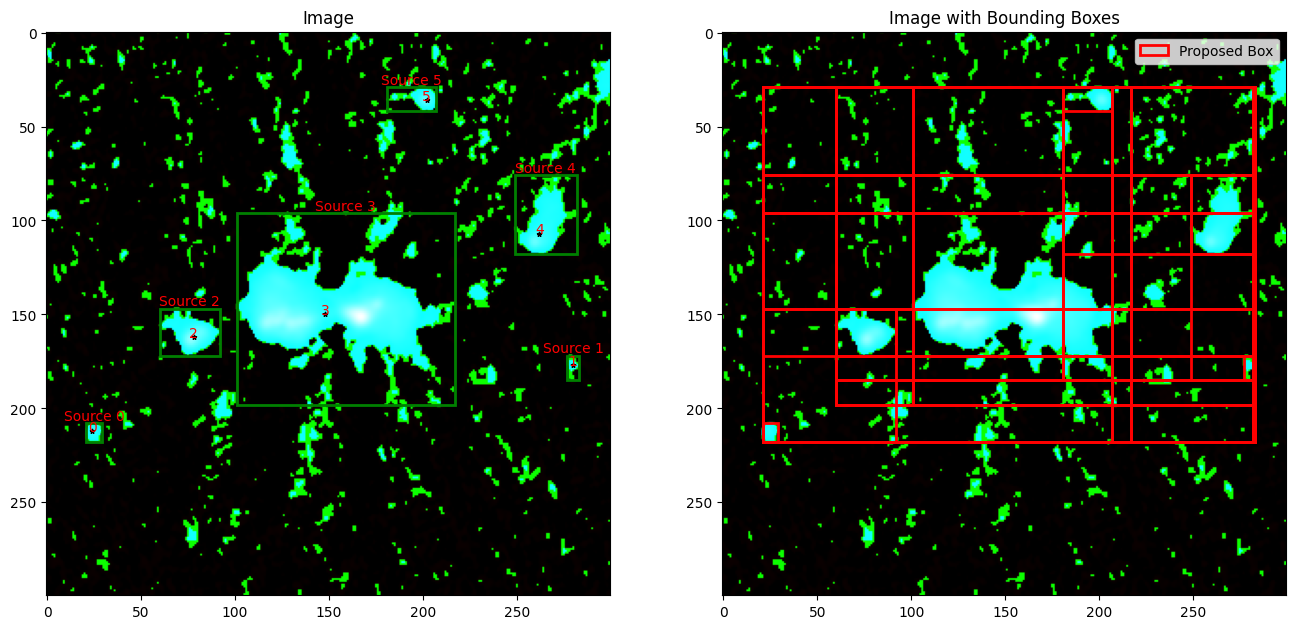

loading annotations into memory...
Done (t=0.86s)
creating index...
index created!
Plotting 127 proposal boxes on image LoTSS_B2S_0000000083_rotated_angle45_RA1.514339_DEC26.608018.png


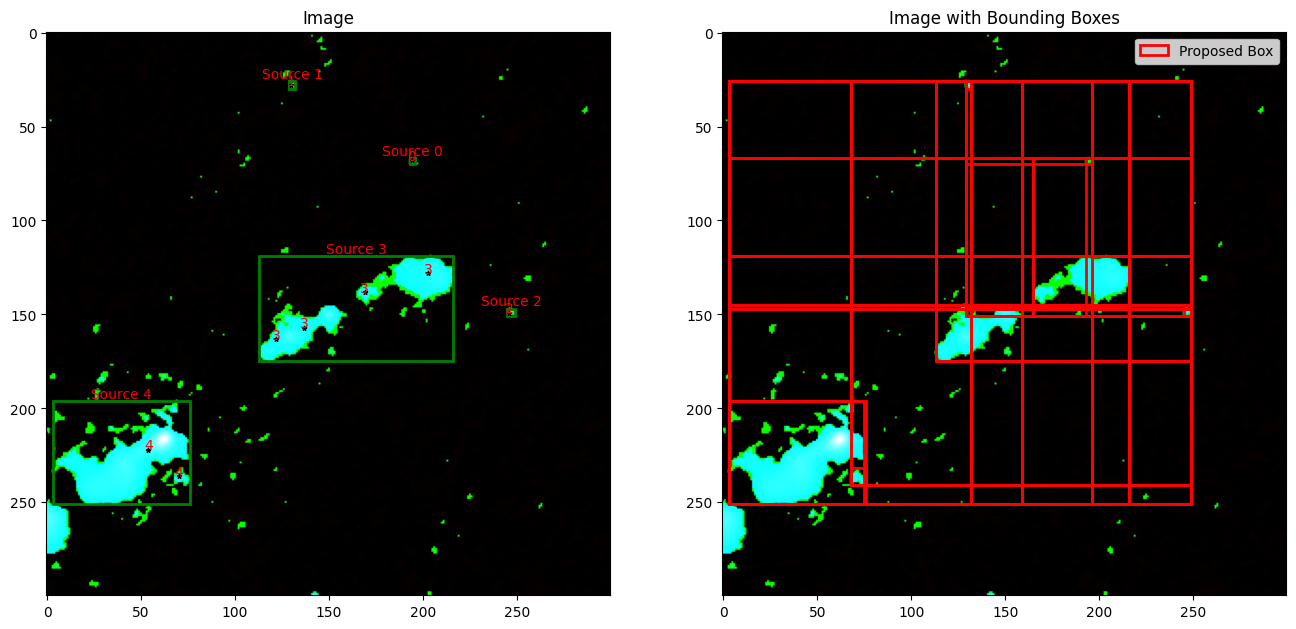

loading annotations into memory...
Done (t=0.64s)
creating index...
index created!
Plotting 255 proposal boxes on image LoTSS_B2S_0000000035_rotated_angle225_RA2.174134_DEC32.851215.png


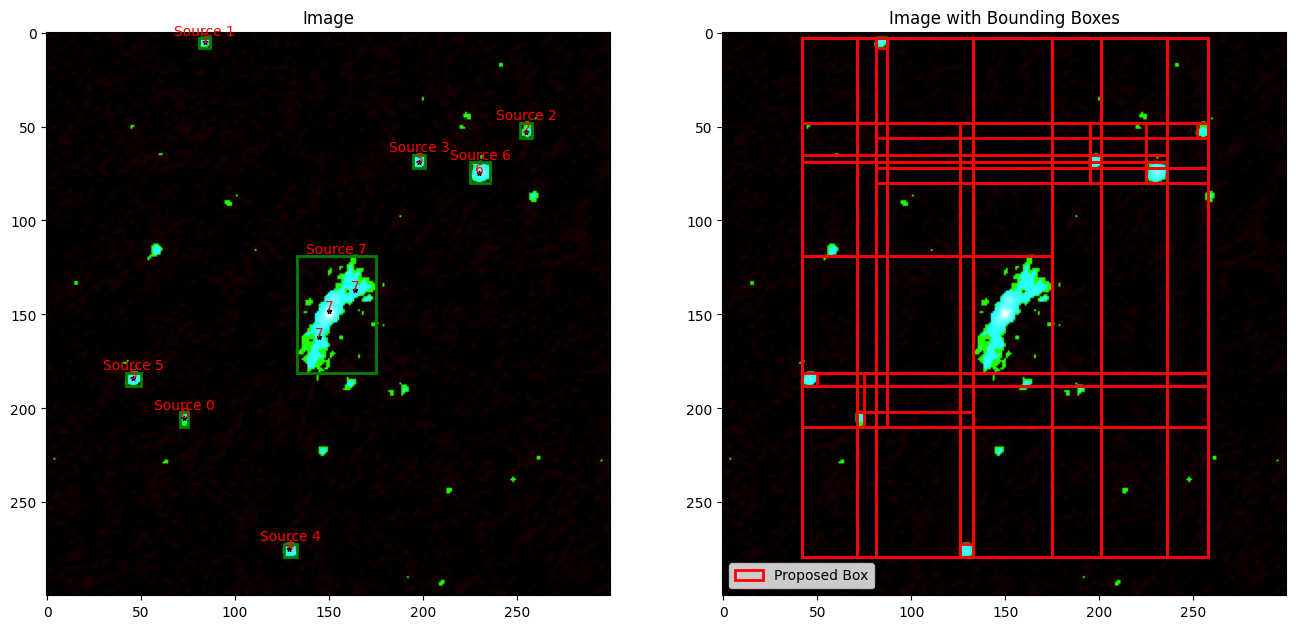

loading annotations into memory...
Done (t=0.65s)
creating index...
index created!
Plotting 255 proposal boxes on image LoTSS_B2S_0000000029_rotated_angle180_RA2.174134_DEC32.851215.png


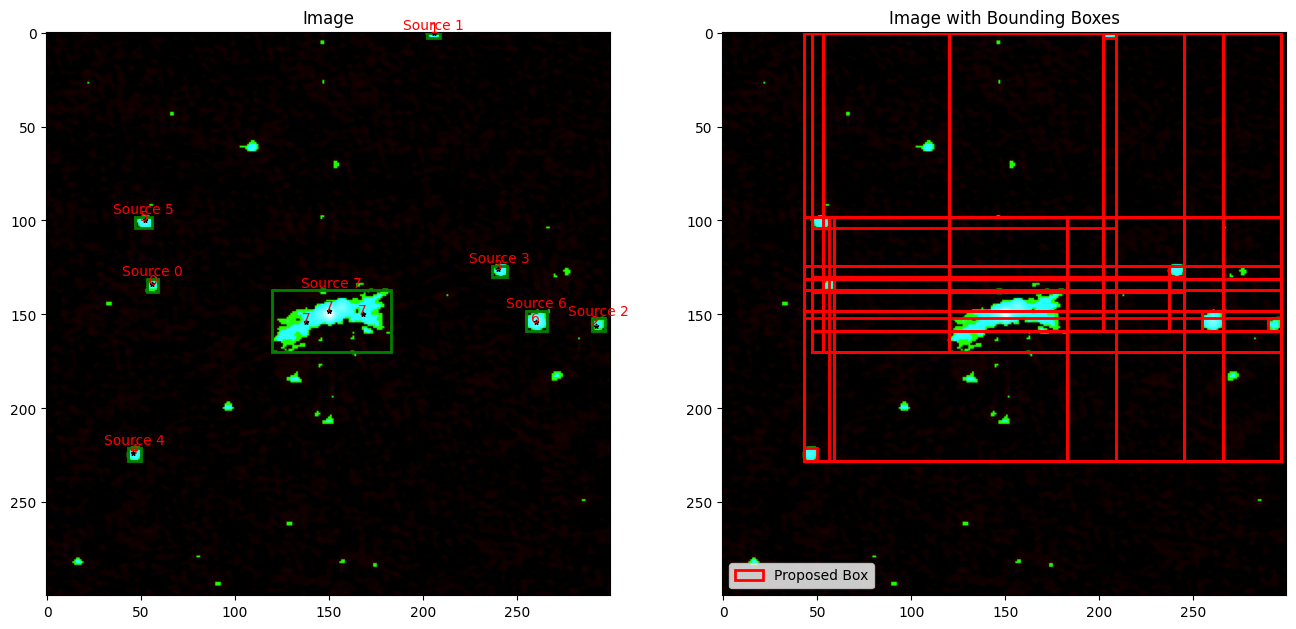

loading annotations into memory...
Done (t=0.65s)
creating index...
index created!
Plotting 7 proposal boxes on image LoTSS_B2S_0000000065_rotated_angle180_RA1.351389_DEC26.351984.png


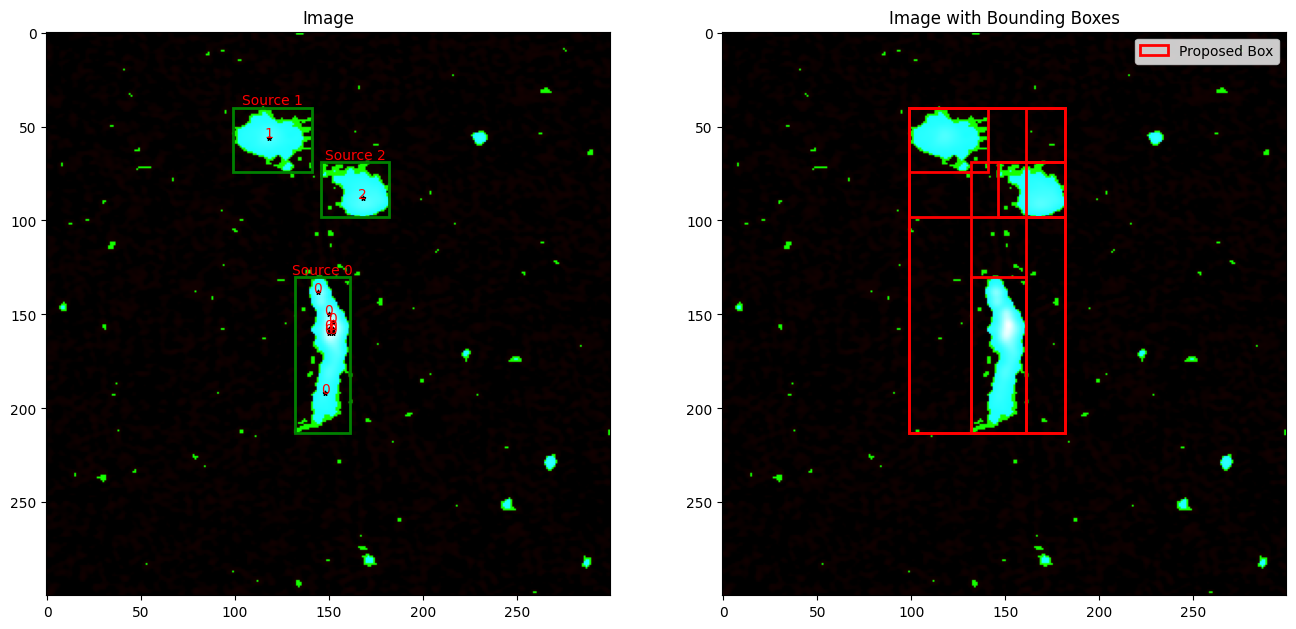

In [6]:
# Generate 8 random numbers from 0-7000
import random
np.random.seed(41)  # Set a seed for reproducibility
random_ids = random.sample(range(100), 8)
for i in random_ids:
    plot_image_with_boxes_proposals(annotations, annotations_path, i)